In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [2]:
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 12, "axes.labelsize": 10})
np.random.seed(42)

Just bringing in the libraries we need. `os` for file paths, `gc` for freeing RAM, `numpy` for math, `pandas` for data, `matplotlib/seaborn` for plots, `sklearn` for scaling and evaluation metrics. `np.random.seed(42)` makes results reproducible  every time you run it you get the same random numbers.

<br><br><br><br><br>

In [ ]:
BASE_PATH   = "/home/memu/Downloads/FinanceDS"
SEQ_LEN     = 20
HIDDEN_SIZE = 32
EPOCHS      = 60
LR          = 0.001
BATCH_SIZE  = 32
MIN_ROWS    = 500
MAX_TICKERS = 30


All the knobs you'd want to tweak in one place. `SEQ_LEN=20` means the model looks at the past 20 trading days to make a prediction. `HIDDEN_SIZE=32` controls how "big" the LSTM is internally  bigger = smarter but slower. `MAX_TICKERS=30` is the main thing keeping your laptop alive, it caps how many stocks/ETFs get loaded per category.

<br><br><br><br><br>

In [4]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_deriv(s):
    return s * (1.0 - s)

def tanh_act(x):
    return np.tanh(x)

def tanh_deriv(t):
    return 1.0 - t ** 2

These are the math functions that run inside the LSTM. `sigmoid` squashes any number into a 0–1 range (useful for gates that decide "how much" to let through). `tanh` squashes into -1 to 1. The `_deriv` versions are their derivatives, used during backpropagation to compute gradients.


<br><br><br><br><br>

# - **Building LSTM** :

In [5]:
class LSTMCell:
    def __init__(self, input_size, hidden_size):
        self.input_dim  = input_size
        self.hidden_dim = hidden_size
        self._init()

    def _init(self):
        nx, nh, s = self.input_dim, self.hidden_dim, 0.1
        self.Wf = np.random.randn(nh, nx).astype(np.float32) * s
        self.Wi = np.random.randn(nh, nx).astype(np.float32) * s
        self.Wc = np.random.randn(nh, nx).astype(np.float32) * s
        self.Wo = np.random.randn(nh, nx).astype(np.float32) * s
        self.Uf = np.random.randn(nh, nh).astype(np.float32) * s
        self.Ui = np.random.randn(nh, nh).astype(np.float32) * s
        self.Uc = np.random.randn(nh, nh).astype(np.float32) * s
        self.Uo = np.random.randn(nh, nh).astype(np.float32) * s
        self.bf = np.ones((nh, 1),  dtype=np.float32)
        self.bi = np.zeros((nh, 1), dtype=np.float32)
        self.bc = np.zeros((nh, 1), dtype=np.float32)
        self.bo = np.zeros((nh, 1), dtype=np.float32)

    def forward(self, x, h_prev, c_prev):
        f = sigmoid(self.Wf @ x + self.Uf @ h_prev + self.bf)
        i = sigmoid(self.Wi @ x + self.Ui @ h_prev + self.bi)
        g = tanh_act(self.Wc @ x + self.Uc @ h_prev + self.bc)
        o = sigmoid(self.Wo @ x + self.Uo @ h_prev + self.bo)
        c = f * c_prev + i * g
        h = o * tanh_act(c)
        return h, c, (x, h_prev, c_prev, f, i, g, o, c, h)

    def backward(self, dh, dc, cache):
        x, h_prev, c_prev, f, i, g, o, c, h = cache
        tanh_c = tanh_act(c)
        do      = tanh_c * dh
        dc      = dc + o * dh * tanh_deriv(tanh_c)
        df      = c_prev * dc
        di      = g * dc
        dg      = i * dc
        dc_prev = f * dc
        dzf = sigmoid_deriv(f) * df
        dzi = sigmoid_deriv(i) * di
        dzc = tanh_deriv(g)   * dg
        dzo = sigmoid_deriv(o) * do
        bs = x.shape[1]
        grads = {
            'Wf': dzf @ x.T / bs,      'Wi': dzi @ x.T / bs,
            'Wc': dzc @ x.T / bs,      'Wo': dzo @ x.T / bs,
            'Uf': dzf @ h_prev.T / bs, 'Ui': dzi @ h_prev.T / bs,
            'Uc': dzc @ h_prev.T / bs, 'Uo': dzo @ h_prev.T / bs,
            'bf': dzf.mean(axis=1, keepdims=True),
            'bi': dzi.mean(axis=1, keepdims=True),
            'bc': dzc.mean(axis=1, keepdims=True),
            'bo': dzo.mean(axis=1, keepdims=True),
        }
        dx      = self.Wf.T @ dzf + self.Wi.T @ dzi + self.Wc.T @ dzc + self.Wo.T @ dzo
        dh_prev = self.Uf.T @ dzf + self.Ui.T @ dzi + self.Uc.T @ dzc + self.Uo.T @ dzo
        return grads, dx, dh_prev, dc_prev


- Creates and initializes all the weights and biases of the LSTM. Uses `float32` instead of float64 to cut RAM usage in half.
  
- The core LSTM step for a single day. Takes yesterday's memory (`c_prev`) and hidden state (`h_prev`), updates them using today's input, and outputs a new hidden state `h`.
  
- Backpropagation through one timestep. Figures out how much each weight contributed to the error so they can be adjusted in the right direction.


<br><br><br><br><br><br><br><br>

In [6]:
class LSTMClassifier:
    def __init__(self, input_size, hidden_size):
        self.cell       = LSTMCell(input_size, hidden_size)
        self.hidden_dim = hidden_size
        self.Wy = (np.random.randn(1, hidden_size) * 0.1).astype(np.float32)
        self.by = np.zeros((1, 1), dtype=np.float32)
        self._adam = {}

    def _forward(self, X):
        seq_len, _, batch_size = X.shape
        h = np.zeros((self.hidden_dim, batch_size), dtype=np.float32)
        c = np.zeros((self.hidden_dim, batch_size), dtype=np.float32)
        caches = []
        for t in range(seq_len):
            h, c, cache = self.cell.forward(X[t], h, c)
            caches.append(cache)
        probs = sigmoid(self.Wy @ h + self.by)
        return probs, h, caches

    def _loss(self, probs, y):
        eps  = 1e-8
        loss = -np.mean(y * np.log(probs + eps) + (1 - y) * np.log(1 - probs + eps))
        dy   = (probs - y) / y.shape[1]
        return loss, dy

    def _backward(self, dy, h_final, caches):
        bs  = dy.shape[1]
        dWy = dy @ h_final.T / bs
        dby = dy.mean(axis=1, keepdims=True)
        dh  = self.Wy.T @ dy
        dc  = np.zeros_like(dh)
        keys = ['Wf','Wi','Wc','Wo','Uf','Ui','Uc','Uo','bf','bi','bc','bo']
        cell_grads = {k: np.zeros_like(getattr(self.cell, k)) for k in keys}
        for cache in reversed(caches):
            grads, _, dh, dc = self.cell.backward(dh, dc, cache)
            for k in keys:
                cell_grads[k] += grads[k]
        return cell_grads, dWy, dby

    def _adam_step(self, param, grad, mk, vk, t, lr):
        b1, b2, eps = 0.9, 0.999, 1e-8
        mk = b1 * mk + (1 - b1) * grad
        vk = b2 * vk + (1 - b2) * grad ** 2
        return param - lr * (mk / (1 - b1**t)) / (np.sqrt(vk / (1 - b2**t)) + eps), mk, vk

    def _update(self, cell_grads, dWy, dby, lr, t):
        keys = ['Wf','Wi','Wc','Wo','Uf','Ui','Uc','Uo','bf','bi','bc','bo']
        if not self._adam:
            for k in keys:
                self._adam[f'm_{k}'] = np.zeros_like(getattr(self.cell, k))
                self._adam[f'v_{k}'] = np.zeros_like(getattr(self.cell, k))
            self._adam['m_Wy'] = np.zeros_like(self.Wy)
            self._adam['v_Wy'] = np.zeros_like(self.Wy)
            self._adam['m_by'] = np.zeros_like(self.by)
            self._adam['v_by'] = np.zeros_like(self.by)

        for k in keys:
            p, mk, vk = self._adam_step(
                getattr(self.cell, k), cell_grads[k],
                self._adam[f'm_{k}'], self._adam[f'v_{k}'], t, lr)
            setattr(self.cell, k, p)
            self._adam[f'm_{k}'] = mk
            self._adam[f'v_{k}'] = vk

        self.Wy, self._adam['m_Wy'], self._adam['v_Wy'] = self._adam_step(
            self.Wy, dWy, self._adam['m_Wy'], self._adam['v_Wy'], t, lr)
        self.by, self._adam['m_by'], self._adam['v_by'] = self._adam_step(
            self.by, dby, self._adam['m_by'], self._adam['v_by'], t, lr)

    def fit(self, X_train, y_train, X_val, y_val, epochs=60, lr=0.001, batch_size=32):
        n = X_train.shape[0]
        train_losses, val_losses, val_accs = [], [], []

        for epoch in range(1, epochs + 1):
            idx     = np.random.permutation(n)
            ep_loss = 0.0
            nb      = 0

            for start in range(0, n, batch_size):
                bi    = idx[start:start + batch_size]
                Xb    = X_train[bi].transpose(1, 2, 0)
                yb    = y_train[bi].T
                probs, h, caches = self._forward(Xb)
                loss, dy = self._loss(probs, yb)
                ep_loss += loss
                nb      += 1
                cg, dWy, dby = self._backward(dy, h, caches)
                self._update(cg, dWy, dby, lr, epoch)

            train_losses.append(ep_loss / nb)

            vp    = self.predict_proba(X_val)
            vloss = float(-np.mean(y_val * np.log(vp + 1e-8) + (1 - y_val) * np.log(1 - vp + 1e-8)))
            vacc  = accuracy_score(y_val, (vp >= 0.5).astype(int))
            val_losses.append(vloss)
            val_accs.append(vacc)

            if epoch % 10 == 0 or epoch == 1:
                print(f"  epoch {epoch:>3}/{epochs}  train={ep_loss/nb:.4f}  val={vloss:.4f}  acc={vacc:.3f}")

        return train_losses, val_losses, val_accs

    def predict_proba(self, X):
        probs, _, _ = self._forward(X.transpose(1, 2, 0))
        return probs.T.squeeze()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)



- Runs the LSTM across all 20 days in a sequence, then converts the final hidden state into a probability of the price going UP tomorrow .
  
- Binary cross-entropy : measures how wrong the model's predictions are. Lower is better. `eps` prevents a crash when `log(0)` would occur.

- Adam optimizer : updates every weight after each batch. Smarter than plain gradient descent because it adjusts the step size per weight based on past gradients.

- The main training loop. Shuffles data, feeds it in batches, and updates weights each time. Tracks val loss and accuracy after every epoch to monitor overfitting.

<br><br><br><br><br><br><br><br><br><br><br><br>


# - **Organizing the data and  everything that loads, cleans, and shapes the data before feeding it to the model**

In [7]:
FEATURES = ["return_1d", "log_return", "sma_r_5", "sma_r_10", "sma_r_20", "vol_10", "rsi", "vol_change"]


In [8]:
def load_tickers(category, min_rows=500, max_tickers=None):
    folder = os.path.join(BASE_PATH, category)
    data   = {}
    files  = sorted(f for f in os.listdir(folder) if f.endswith(".csv"))
    if max_tickers:
        files = files[:max_tickers]
    for fname in files:
        ticker = fname.replace(".csv", "").upper()
        try:
            df = pd.read_csv(os.path.join(folder, fname))
            df.columns = [c.strip().title() for c in df.columns]
            date_col = next((c for c in df.columns if "date" in c.lower()), None)
            if date_col:
                df[date_col] = pd.to_datetime(df[date_col])
                df = df.rename(columns={date_col: "Date"}).sort_values("Date").reset_index(drop=True)
            required = ["Open", "High", "Low", "Close", "Volume"]
            if not all(c in df.columns for c in required):
                continue
            df = df.dropna(subset=required)
            if len(df) < min_rows:
                continue
            df["ticker"]   = ticker
            df["category"] = category
            keep = (["Date"] + required + ["ticker", "category"]) if "Date" in df.columns else (required + ["ticker", "category"])
            data[ticker] = df[keep]
        except Exception as e:
            print(f"  skipping {ticker}: {e}")
    print(f"  loaded {len(data)} {category} tickers")
    return data


Reads CSVs from the stocks or etfs folder. Skips tickers with missing columns or too few rows. Only keeps the columns it needs to save memory.


<br><br><br><br><br><br><br><br><br><br><br><br>

In [9]:
def make_features(df):
    d = df.copy()
    c = d["Close"]
    d["return_1d"]  = c.pct_change()
    d["log_return"] = np.log(c / c.shift(1))
    for w in [5, 10, 20]:
        sma = c.rolling(w).mean()
        d[f"sma_r_{w}"] = c / (sma + 1e-8) - 1
    d["vol_10"]     = d["return_1d"].rolling(10).std()
    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d["rsi"]        = 100 - 100 / (1 + gain / (loss + 1e-8))
    d["vol_change"] = d["Volume"].pct_change()
    d["target"]     = (c.shift(-1) > c).astype(int)
    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    return d.dropna().reset_index(drop=True)


Builds 8 technical features from raw price data and creates the target label (1 = price goes up tomorrow, 0 = goes down). Replaces any `inf` values so the scaler doesn't crash.

<br><br><br><br><br><br><br><br><br><br><br><br>

In [10]:
def make_sequences(df, seq_len=20):
    feats  = df[FEATURES].values.astype(np.float32)
    tgt    = df["target"].values.astype(np.float32)
    scaler = MinMaxScaler(feature_range=(-1, 1))
    feats  = scaler.fit_transform(feats).astype(np.float32)
    X, y   = [], []
    for i in range(seq_len, len(feats) - 1):
        X.append(feats[i - seq_len:i])
        y.append(tgt[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


Turns the feature table into sliding windows of 20 days. Each window is one training sample. Scales everything to [-1, 1] so different price ranges don't interfere.


<br><br><br><br><br><br><br><br><br><br><br><br>

In [11]:
def split(X, y, val=0.15, test=0.15):
    n  = len(X)
    nt = int(n * test)
    nv = int(n * val)
    nr = n - nv - nt
    return X[:nr], y[:nr], X[nr:nr+nv], y[nr:nr+nv], X[nr+nv:], y[nr+nv:]



Takes the full sequence array and cuts it into 3 pieces train, validation, and test based on percentages. With the defaults of val=0.15 and test=0.15, if you have 1000 samples it gives you 700 for training, 150 for validation, and 150 for testing.

<br><br><br><br><br><br><br><br><br><br><br><br>

In [12]:
def build_dataset(ticker_dict, seq_len=20):
    trs_X, trs_y = [], []
    vas_X, vas_y = [], []
    tes_X, tes_y = [], []
    for ticker, raw_df in ticker_dict.items():
        df = make_features(raw_df)
        if len(df) < seq_len + 50:
            continue
        X, y = make_sequences(df, seq_len)
        Xtr, ytr, Xva, yva, Xte, yte = split(X, y)
        trs_X.append(Xtr); trs_y.append(ytr)
        vas_X.append(Xva); vas_y.append(yva)
        tes_X.append(Xte); tes_y.append(yte)
        del df, X, y, Xtr, ytr, Xva, yva, Xte, yte
        gc.collect()
    return (np.concatenate(trs_X), np.concatenate(trs_y),
            np.concatenate(vas_X), np.concatenate(vas_y),
            np.concatenate(tes_X), np.concatenate(tes_y))


Builds sequences for every ticker and stacks them into one big dataset. Deletes intermediate arrays after each ticker to keep RAM usage low.

<br><br><br><br><br><br><br><br><br><br><br><br>

# - **Running it where everything actually executes**

In [13]:
def train_model(category, ticker_dict):
    
    print(f"  {category.upper()}")
    

    Xtr, ytr, Xva, yva, Xte, yte = build_dataset(ticker_dict, SEQ_LEN)
    print(f"  train={Xtr.shape}  val={Xva.shape}  test={Xte.shape}")
    print(f"  class balance — UP: {ytr.mean():.2%}  DOWN: {(1-ytr).mean():.2%}")

    model = LSTMClassifier(input_size=Xtr.shape[2], hidden_size=HIDDEN_SIZE)
    train_losses, val_losses, val_accs = model.fit(
        Xtr, ytr.reshape(-1, 1),
        Xva, yva.reshape(-1, 1),
        epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE
    )

    y_prob = model.predict_proba(Xte)
    y_pred = (y_prob >= 0.5).astype(int)
    acc    = accuracy_score(yte, y_pred)
    auc    = roc_auc_score(yte, y_prob)

    print(f"\n  test accuracy={acc:.4f}  roc-auc={auc:.4f}")
    print(classification_report(yte, y_pred, target_names=["DOWN", "UP"]))

    del Xtr, ytr, Xva, yva
    gc.collect()

    return dict(
        model=model, category=category,
        train_losses=train_losses, val_losses=val_losses, val_accs=val_accs,
        y_true=yte, y_pred=y_pred, y_prob=y_prob,
        acc=acc, auc=auc
    )


Puts everything together for one category builds data, trains the model, and evaluates it on the test set. Reports accuracy and AUC (0.5 = random, 1.0 = perfect).

<br><br><br><br><br><br><br><br><br><br><br><br>

In [14]:
def plot_eda(stocks, etfs):
    records = []
    for cat, d in [("stocks", stocks), ("etfs", etfs)]:
        for ticker, df in d.items():
            records.append({
                "ticker": ticker, "category": cat,
                "rows": len(df),
                "avg_close":  df["Close"].mean(),
                "avg_volume": df["Volume"].mean(),
            })
    meta = pd.DataFrame(records)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Dataset Overview", fontsize=13, fontweight="bold")

    for cat, grp in meta.groupby("category"):
        axes[0].hist(grp["rows"], bins=25, alpha=0.65, label=cat.upper())
    axes[0].set_title("Rows per Ticker")
    axes[0].set_xlabel("# rows")
    axes[0].legend()

    counts = meta.groupby("category").size()
    axes[1].bar(counts.index, counts.values, color=["#4C9BE8", "#E8854C"])
    axes[1].set_title("Ticker Count")
    for i, (cat, v) in enumerate(counts.items()):
        axes[1].text(i, v + 1, str(v), ha="center", fontweight="bold")

    for cat, grp in meta.groupby("category"):
        axes[2].hist(np.log10(grp["avg_volume"] + 1), bins=25, alpha=0.65, label=cat.upper())
    axes[2].set_title("Avg Volume (log10)")
    axes[2].set_xlabel("log10(volume)")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("eda_overview.png", bbox_inches="tight")
    plt.show()
    return meta

3 charts giving an overview of the raw dataset before training rows per ticker, ticker count per category, and volume distribution.

<br><br><br><br><br><br><br><br><br><br><br><br>

In [15]:
def plot_results(stocks_res, etfs_res):
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.35)
    colors = {"stocks": "#4C9BE8", "etfs": "#E8854C"}

    for col, res in enumerate([stocks_res, etfs_res]):
        cat    = res["category"]
        c      = colors[cat]
        epochs = range(1, len(res["train_losses"]) + 1)
        ax     = fig.add_subplot(gs[0, col * 2: col * 2 + 2])
        ax.plot(epochs, res["train_losses"], color=c, alpha=0.85, label="train loss")
        ax.plot(epochs, res["val_losses"],   color=c, alpha=0.4, linestyle="--", label="val loss")
        ax2 = ax.twinx()
        ax2.plot(epochs, res["val_accs"], color="gold", linewidth=1.5, label="val acc")
        ax2.set_ylabel("val accuracy", color="gold")
        ax2.tick_params(axis="y", labelcolor="gold")
        ax.set_title(f"{cat.upper()} — training curves")
        ax.set_xlabel("epoch")
        ax.set_ylabel("bce loss")
        ax.legend(loc="upper left", fontsize=8)

    for col, res in enumerate([stocks_res, etfs_res]):
        ax = fig.add_subplot(gs[1, col * 2: col * 2 + 2])
        cm = confusion_matrix(res["y_true"], res["y_pred"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["DOWN", "UP"], yticklabels=["DOWN", "UP"], ax=ax)
        ax.set_title(f"{res['category'].upper()} — confusion matrix\nacc={res['acc']:.3f}  auc={res['auc']:.3f}")
        ax.set_xlabel("predicted")
        ax.set_ylabel("actual")

    for col, res in enumerate([stocks_res, etfs_res]):
        ax = fig.add_subplot(gs[2, col * 2: col * 2 + 2])
        up = res["y_true"] == 1
        ax.hist(res["y_prob"][up],  bins=35, alpha=0.6, color="green", label="true UP")
        ax.hist(res["y_prob"][~up], bins=35, alpha=0.6, color="red",   label="true DOWN")
        ax.axvline(0.5, color="white", linestyle="--", linewidth=1.5)
        ax.set_title(f"{res['category'].upper()} — predicted probability")
        ax.set_xlabel("P(UP)")
        ax.set_ylabel("count")
        ax.legend(fontsize=9)

    fig.suptitle("LSTM Price Direction — Stocks vs ETFs", fontsize=14, fontweight="bold")
    plt.savefig("lstm_results.png", bbox_inches="tight")
    plt.show()


3 rows of charts comparing stocks vs ETFs  training curves, confusion matrix, and prediction confidence histogram. Saved as `lstm_results.png`.

<br><br><br><br><br><br><br><br><br><br><br><br>

loading stocks...
  loaded 29 stocks tickers
loading etfs...
  loaded 20 etfs tickers

running EDA...


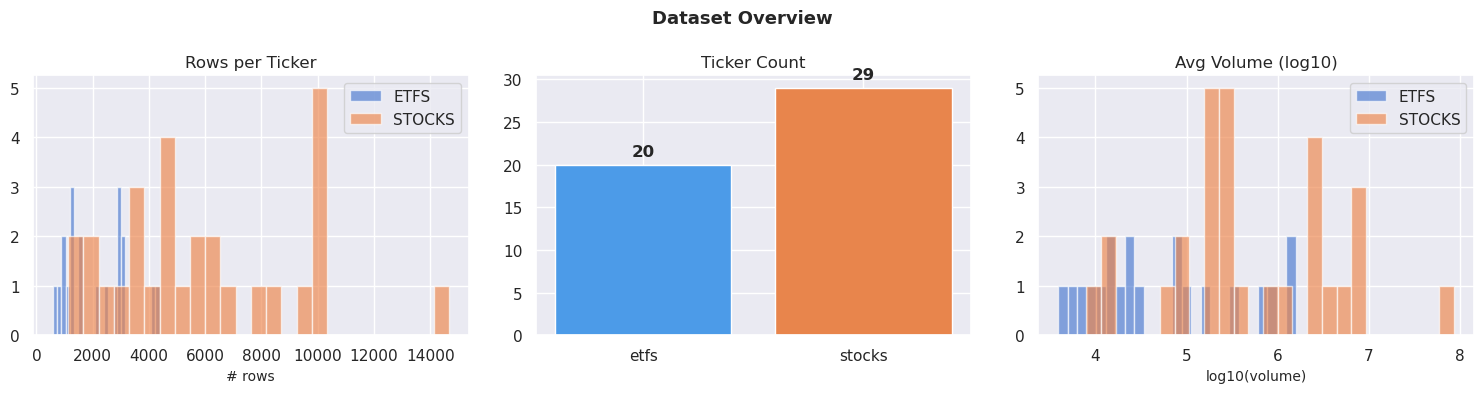

category                  etfs        stocks
rows       count  2.000000e+01  2.900000e+01
           mean   2.104400e+03  5.943621e+03
           std    1.123219e+03  3.307540e+03
           min    5.780000e+02  1.128000e+03
           25%    1.170500e+03  3.622000e+03
           50%    1.853500e+03  5.124000e+03
           75%    2.933000e+03  8.236000e+03
           max    4.374000e+03  1.466300e+04
avg_close  count  2.000000e+01  2.900000e+01
           mean   4.829518e+01  6.693574e+03
           std    2.877198e+01  3.205200e+04
           min    1.588519e+01  1.599733e+00
           25%    2.683422e+01  1.451370e+01
           50%    4.121252e+01  2.696916e+01
           75%    5.597220e+01  3.656334e+01
           max    1.121912e+02  1.720976e+05
avg_volume count  2.000000e+01  2.900000e+01
           mean   2.683183e+05  4.631307e+06
           std    4.762358e+05  1.582478e+07
           min    3.902105e+03  7.977758e+03
           25%    1.289380e+04  2.009383e+05
          

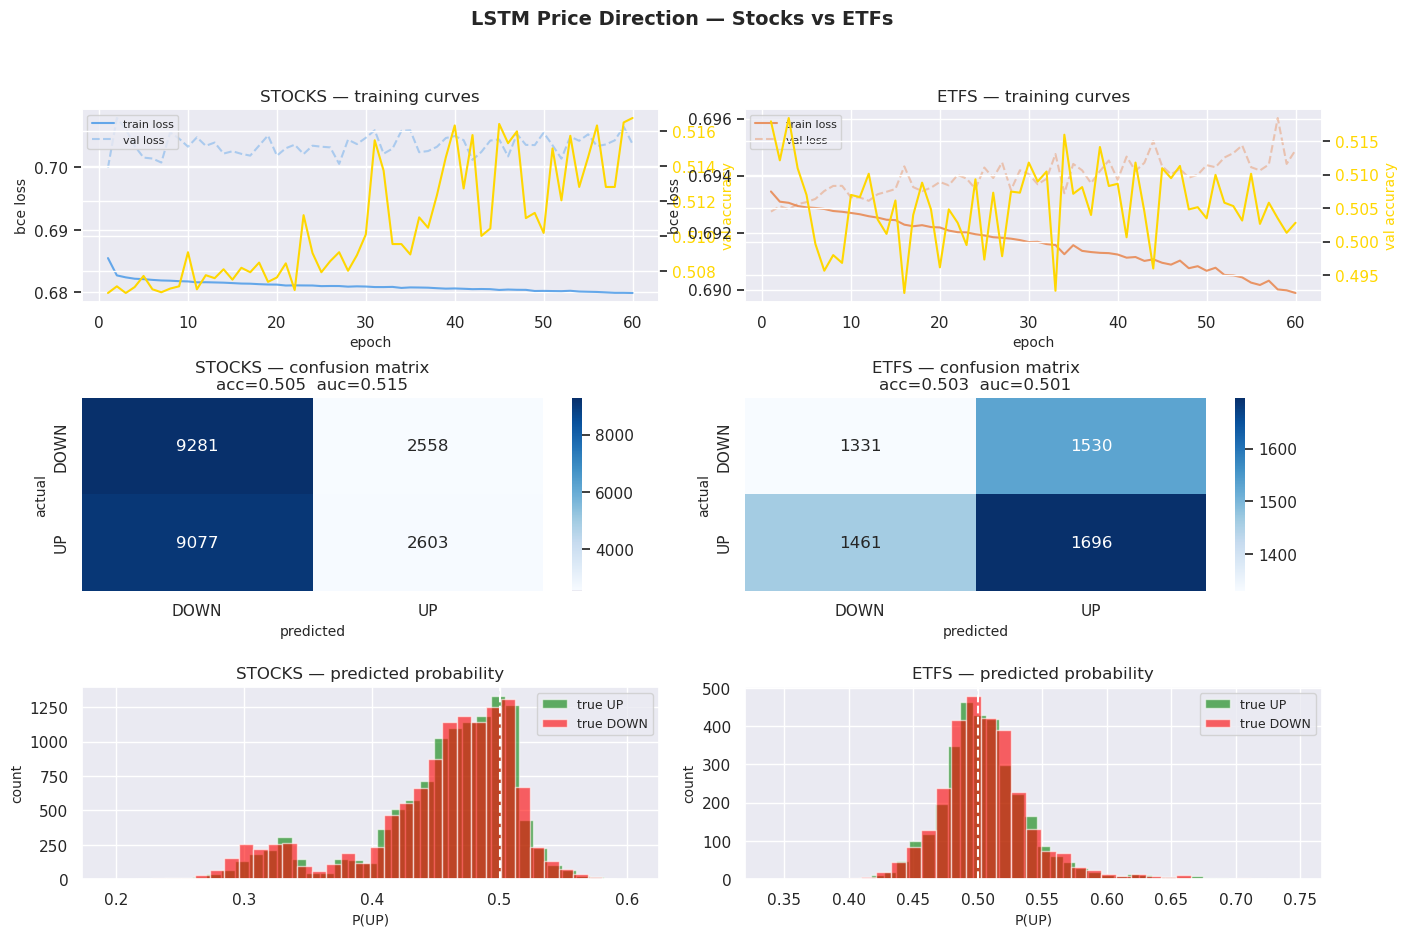


stocks  →  acc: 0.5053   auc: 0.5152
etfs    →  acc: 0.5030   auc: 0.5009


In [16]:
print("loading stocks...")
stocks_dict = load_tickers("stocks", MIN_ROWS, MAX_TICKERS)

print("loading etfs...")
etfs_dict = load_tickers("etfs", MIN_ROWS, MAX_TICKERS)

print("\nrunning EDA...")
meta = plot_eda(stocks_dict, etfs_dict)
print(meta.groupby("category")[["rows", "avg_close", "avg_volume"]].describe().T)

stocks_res = train_model("stocks", stocks_dict)
etfs_res   = train_model("etfs",   etfs_dict)

plot_results(stocks_res, etfs_res)

print(f"\nstocks  →  acc: {stocks_res['acc']:.4f}   auc: {stocks_res['auc']:.4f}")
print(f"etfs    →  acc: {etfs_res['acc']:.4f}   auc: {etfs_res['auc']:.4f}")
